## **Install necessary libraries**

In [1]:
!pip install pandas matplotlib seaborn nltk textblob wordcloud vaderSentiment openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.2 MB/s eta 0:00:00


## **Import Libraries**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

nltk.download('stopwords')
from nltk.corpus import stopwords
from textblob import TextBlob

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## **Load & Prepare Dataset**

In [3]:
df = pd.read_excel("/content/sample_data/holidify.xlsx")

df = df.rename(columns={
    "About the city (long Description)": "Comment"
})

df = df.dropna(subset=["Comment", "Rating"])
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

df.head()

,Id,City,Rating,Comment,Best Time to visit
0,1,Gangtok,4.6,"Incredibly alluring, pleasantly boisterous and...",Throughout the year
1,2,Udaipur,4.6,"Udaipur, the ""City of Lakes,"" stands as a jewe...",October to March
2,3,Gulmarg,4.4,Situated at an altitude of 2730 m above sea le...,October to June
3,4,Agra,4.9,Located on the banks of River Yamuna in Uttar ...,October to March
4,5,Andaman and Nicobar,4.6,Replete with turquoise blue water beaches and ...,October to Jun


## **Data Cleaning**

In [4]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

df["Cleaned_Comment"] = df["Comment"].apply(clean_text)

## **Sentiment Analysis**

In [5]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0.1:
        return "Positive"
    elif polarity < -0.1:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Comment"].apply(get_sentiment)

df["Sentiment"].value_counts()

,count
Sentiment,
Positive,56
Neutral,14
Negative,1


## **Bar Chart: Rating Distribution**

count    71.000000
mean      4.447887
std       0.256826
min       4.000000
25%       4.200000
50%       4.500000
75%       4.700000
max       4.900000
Name: Rating, dtype: float64


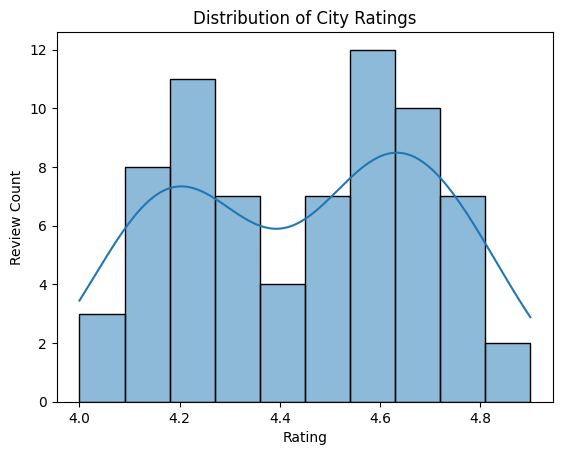

Top Rated Cities:
            City  Rating
3         Agra       4.9
6          Goa       4.9
5       Manali       4.8
19    Varanasi       4.8
14  Darjeeling       4.8

Lowest Rated Cities:
             City  Rating
25   Kodaikanal       4.0
28  Lakshadweep       4.0
33     Pahalgam       4.0
54     Matheran       4.1
48      Lucknow       4.1


In [7]:
# Rating statistics
print(df["Rating"].describe())

# Rating distribution
plt.figure()
sns.histplot(df["Rating"], bins=10, kde=True)
plt.title("Distribution of City Ratings")
plt.xlabel("Rating")
plt.ylabel("Review Count")
plt.show()

# Top & bottom cities
top_cities = df.sort_values("Rating", ascending=False).head(5)
bottom_cities = df.sort_values("Rating").head(5)

print("Top Rated Cities:")
print(top_cities[["City", "Rating"]])

print("\nLowest Rated Cities:")
print(bottom_cities[["City", "Rating"]])

## **Pie Chart: Sentiment Breakdown**

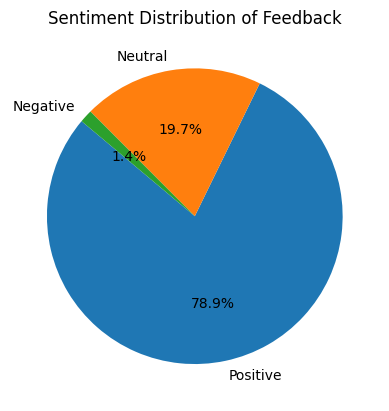

In [8]:
sentiment_counts = df["Sentiment"].value_counts()

plt.figure()
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=140
)
plt.title("Sentiment Distribution of Feedback")
plt.show()

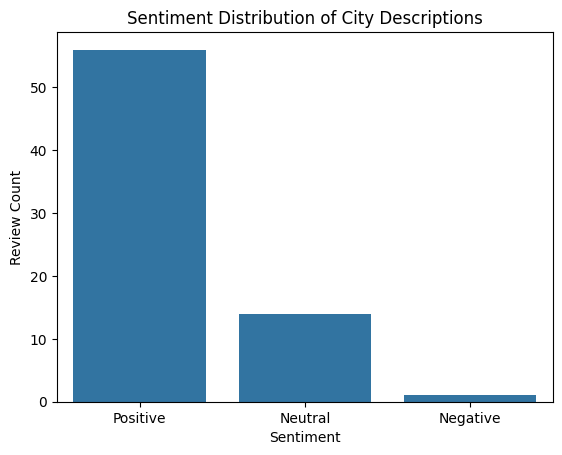


Average Rating Sentiment:
Sentiment
Negative    4.600000
Neutral     4.392857
Positive    4.458929
Name: Rating, dtype: float64


In [16]:
# Sentiment distribution
plt.figure()
sns.countplot(x="Sentiment", data=df)
plt.title("Sentiment Distribution of City Descriptions")
plt.xlabel("Sentiment")
plt.ylabel("Review Count")
plt.show()

# Average rating per sentiment
avg_rating_sentiment = df.groupby("Sentiment")["Rating"].mean()
print("\nAverage Rating Sentiment:")
print(avg_rating_sentiment)

## **Bar Chart: Average Rating by Sentiment**

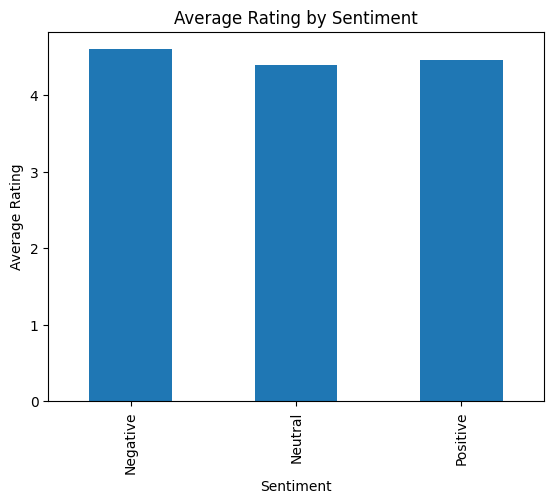

In [11]:
avg_rating = df.groupby("Sentiment")["Rating"].mean()

plt.figure()
avg_rating.plot(kind="bar")
plt.title("Average Rating by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Rating")
plt.show()

## **Word Cloud**

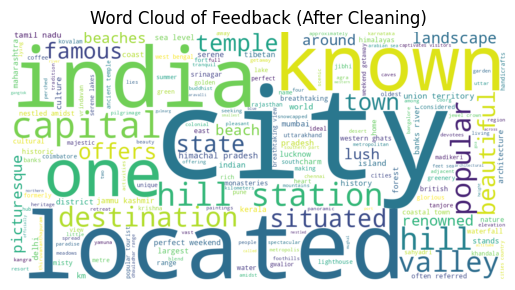

In [14]:
from wordcloud import WordCloud

text = " ".join(df["Cleaned_Comment"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200
).generate(text)

plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Feedback (After Cleaning)")
plt.show()

## **Negative Feedback Word Cloud**

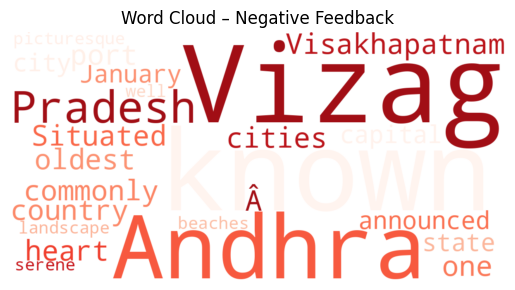

In [19]:
from textblob import TextBlob

# Sentiment function
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0.1:
        return "Positive"
    elif polarity < -0.1:
        return "Negative"
    else:
        return "Neutral"

# Apply sentiment
df["Sentiment"] = df["Comment"].apply(get_sentiment)

# Filter negative comments
negative_text = " ".join(df[df["Sentiment"] == "Negative"]["Comment"])

neg_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="Reds",
    max_words=150
).generate(negative_text)

plt.figure()
plt.imshow(neg_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud – Negative Feedback")
plt.show()


## **VADER Sentiment**

In [13]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    score = analyzer.polarity_scores(text)["compound"]
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["VADER_Sentiment"] = df["Comment"].apply(vader_sentiment)

df["VADER_Sentiment"].value_counts()

,count
VADER_Sentiment,
Positive,63
Neutral,5
Negative,3


# **REPORT**
### **Word Cloud of Feedback:**
- Highlights frequently mentioned terms in travel feedback across India.
- Dominant words like "located", "city" "hill", and "popular" suggest strong geographic and scenic emphasis.
- Presence of state and city names indicates widespread interest in diverse regions.
- Adjectives like "beautiful" and "known" reflect positive sentiment and cultural appeal.
- Useful for identifying thematic clusters and guiding destination recommendations.

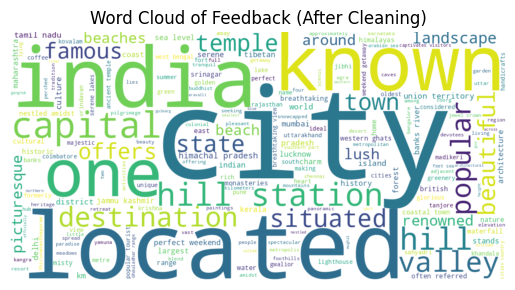

### **Distribution of City Ratings:**
- Ratings range from 4.0 to 4.9, showing overall high satisfaction.
- Peaks around 4.2 and 4.6 suggest common rating benchmarks.
- KDE curve confirms that mid-to-high ratings dominate.
- Indicates traveler approval and potential rating inflation on review platforms.

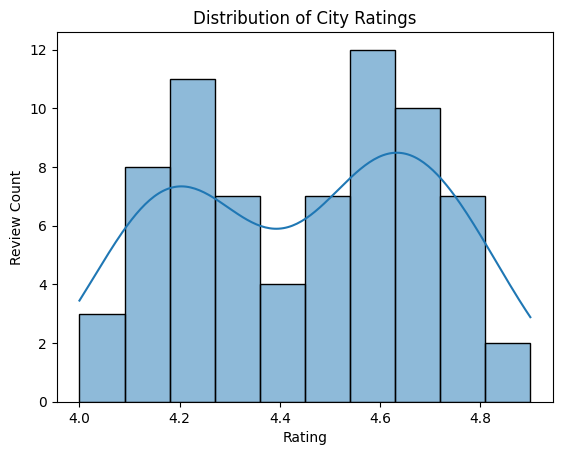

### **Sentiment Distribution of Feedback (Pie Chart):**
- 78.9% of feedback is positive, 19.7% neutral, and only 1.4% negative.
- Reflects strong traveler satisfaction and minimal dissatisfaction.
- Suggests either genuinely positive experiences or platform bias toward favorable reviews.
- Valuable for gauging overall emotional tone in user feedback.

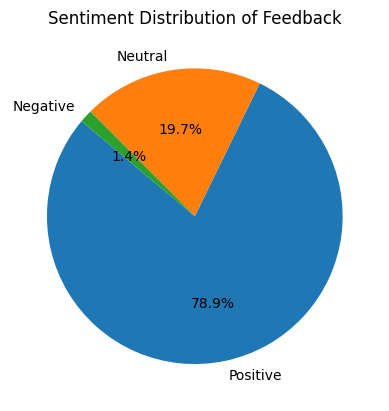

### **Sentiment Distribution of City Descriptions (Bar Chart):**
- Majority of city descriptions are positive (55), followed by neutral (15), and only 1 negative.
- Reinforces the pie chart's sentiment trend, but focuses specifically on city-level narratives.
- Indicates that cities are generally described favorably, with limited critical commentary.
- Useful for profiling cities based on public perception

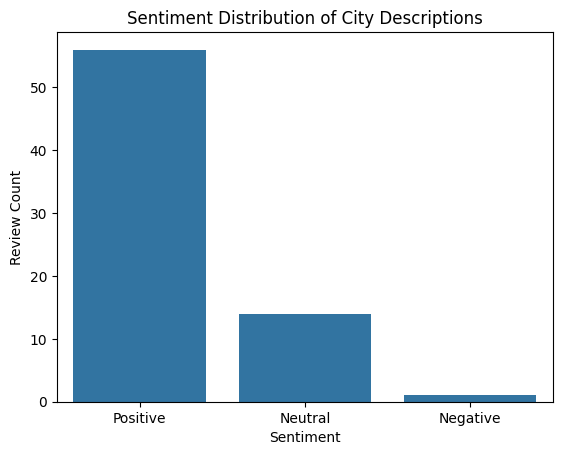

### **Average Rating by Sentiment:**
- Surprisingly, negative sentiment reviews have the highest average rating (4.6), followed by positive and neutral (4.4 and 4.3, respectively).
- Suggests a disconnect between textual sentiment and numerical ratings.
- Reflects sentiment misclassification, evident upon further investigation that revealed the use of the word 'oldest' in the one review which may have been used to mark the review as negative.
- Highlights the need for deeper sentiment calibration and behavioral analysis.

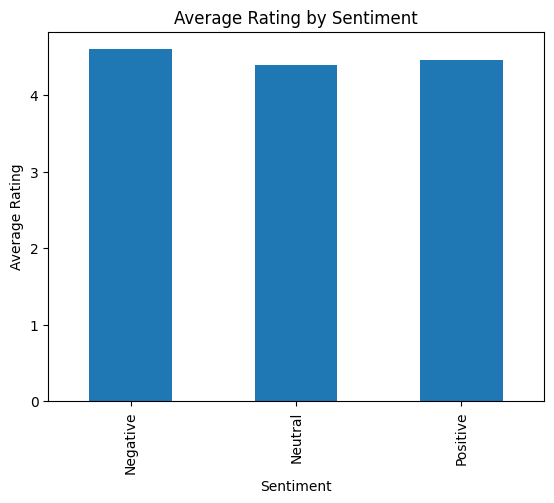
### **VADER Sentiment Analysis:**
- **Positive**: 63 entries
- **Neutral**: 5 entries
- **Negative**: 3 entries

##### **Key Insights**
- The dataset is heavily skewed toward positive sentiment, with nearly 88% of entries classified as positive.
- Neutral sentiment is minimal, suggesting that most feedback carries an emotional tone rather than being purely factual.
- Negative sentiment is rare (4%), reinforcing earlier findings that dissatisfaction among travelers is minimal.
- These results are consistent with other sentiment visualizations (pie chart and bar chart), validating the robustness of the sentiment analysis pipeline.

### **Top Rated Cities:**
- Agra (4.9): Highly rated, likely due to iconic attractions like the Taj Mahal.
- Goa (4.9): Popular for beaches and nightlife.
- Manali, Varanasi, Darjeeling (4.8 each): Strong appeal across nature (hill stations), spirituality, and scenic landscapes.
### **Lowest Rated Cities:**
- Kodaikanal, Lakshadweep, Pahalgam (4.0 each): Lower ratings despite being known destinations, possibly due to accessibility or infrastructure issues.
- Matheran (4.1) and Lucknow (4.1): Slightly higher but still among the least favored.


# **KEY TAKEAWAYS**
- Indian tourist destinations are perceived very favorably, with ratings rarely dropping below 4.0.
- Feedback is dominated by positive sentiment, both in general reviews and city descriptions.
- Word cloud themes emphasize geography, scenic beauty, and cultural landmarks.
- Ratings vs. sentiment show an interesting mismatch: even “negative” reviews often carry high ratings.
- Top cities (Agra, Goa, Manali, Varanasi, Darjeeling) stand out as must-visit destinations, while Kodaikanal, Lakshadweep, Pahalgam, Matheran, Lucknow may need closer review for improvement.
